In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append(r'C:\Users\abdal\Desktop\projects\ML\ML_project\src')
# Données BRUTES (avant nettoyage) → pour visualiser la réalité
df_raw = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\raw\retail_customers_COMPLETE CATEGORICAL.csv')
# Charger les données NETTOYÉES (pas le CSV brut !)
df = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\processed\data_clean.csv')
print(f" Données brutes chargées : {df_raw.shape}")

 Données brutes chargées : (4372, 52)


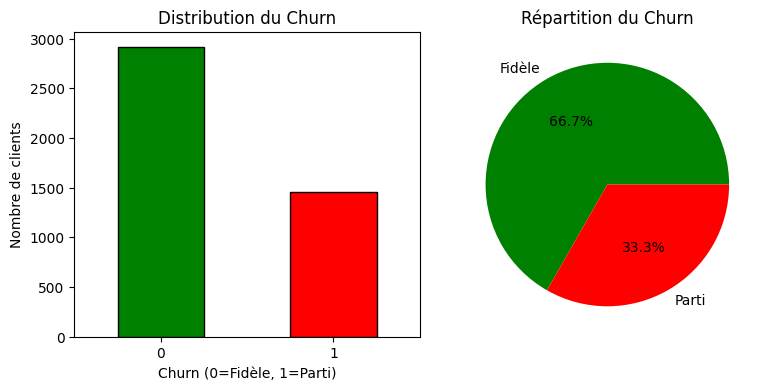

Churn
0    2918
1    1454
Name: count, dtype: int64

En pourcentage :
Churn
0    66.74
1    33.26
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(8, 4))

# Graphique
plt.subplot(1, 2, 1)
df_raw['Churn'].value_counts().plot(
    kind='bar', 
    color=['green', 'red'],
    edgecolor='black'
)
plt.title('Distribution du Churn')
plt.xlabel('Churn (0=Fidèle, 1=Parti)')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)

# Camembert
plt.subplot(1, 2, 2)
df_raw['Churn'].value_counts().plot(
    kind='pie',
    labels=['Fidèle', 'Parti'],
    colors=['green', 'red'],
    autopct='%1.1f%%'
)
plt.title('Répartition du Churn')

plt.tight_layout()
plt.show()

# Chiffres
print(df_raw['Churn'].value_counts())
print("\nEn pourcentage :")
print((df_raw['Churn'].value_counts(normalize=True) * 100).round(2))
# onconclut qu'on un a un déséquilibre modéré (environ 70% de fidèles et 30% de partis).'


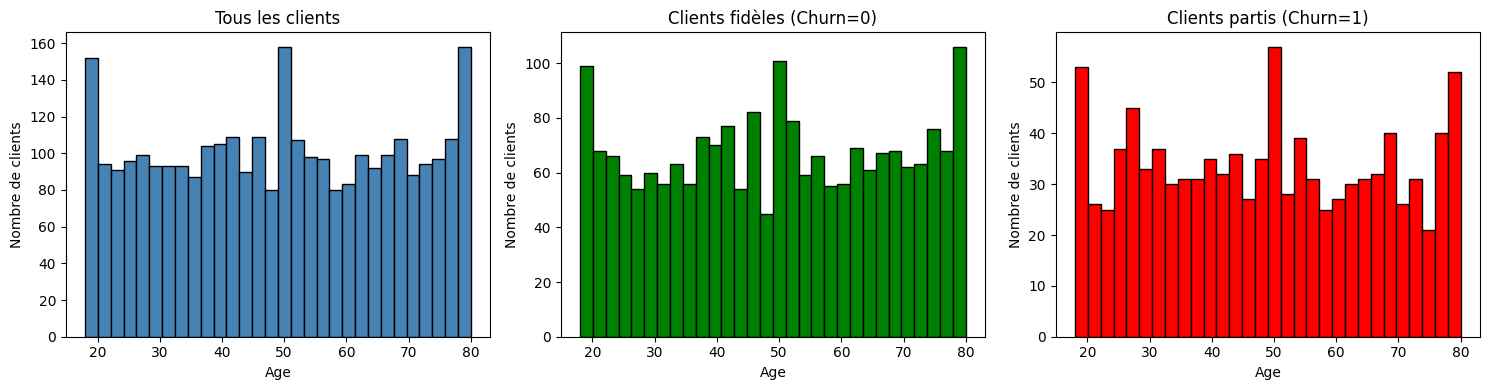

Moyenne d'âge :
Tous les clients : 49.1 ans
Clients fidèles  : 49.4 ans
Clients partis   : 48.6 ans


In [3]:
plt.figure(figsize=(15, 4))

# Graphique 1 — Tous les clients
plt.subplot(1, 3, 1)
plt.hist(df_raw['Age'].dropna(), bins=30,
         color='steelblue', edgecolor='black')
plt.title('Tous les clients')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

# Graphique 2 — Clients fidèles seulement
plt.subplot(1, 3, 2)
plt.hist(df_raw[df_raw['Churn']==0]['Age'].dropna(), bins=30,
         color='green', edgecolor='black')
plt.title('Clients fidèles (Churn=0)')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

# Graphique 3 — Clients partis seulement
plt.subplot(1, 3, 3)
plt.hist(df_raw[df_raw['Churn']==1]['Age'].dropna(), bins=30,
         color='red', edgecolor='black')
plt.title('Clients partis (Churn=1)')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')

plt.tight_layout()
plt.show()

# Statistiques
print("Moyenne d'âge :")
print(f"Tous les clients : {df_raw['Age'].mean():.1f} ans")
print(f"Clients fidèles  : {df_raw[df_raw['Churn']==0]['Age'].mean():.1f} ans")
print(f"Clients partis   : {df_raw[df_raw['Churn']==1]['Age'].mean():.1f} ans")
# L'âge n'est PAS une feature importante pour prédire le Churn

In [4]:
correlation = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)


In [5]:
correlation

Churn                          1.000000
Recency                        0.858951
TenureRatio                    0.607105
FavoriteSeason_Printemps       0.295996
ProductDiversity_Modéré        0.233466
FirstPurchaseDaysAgo           0.221612
FavoriteSeason_Hiver           0.209387
FavoriteSeason_Été             0.168132
ProductDiversity_Spécialisé    0.165510
ReturnRatio                    0.093914
Region_Moyen-Orient            0.047504
Region_Autre                   0.037935
Region_Europe centrale         0.029578
Region_Amérique du Nord        0.026575
Region_Europe de l'Est         0.021427
Region_Amérique du Sud         0.021427
SatisfactionScore              0.019465
WeekendPreference_Weekend      0.016714
Region_Europe du Sud           0.012521
Region_Asie                    0.010785
PreferredDayOfWeek             0.009435
Gender_Unknown                 0.007603
AvgQuantityPerTransaction      0.002528
Region_UK                      0.000584
IP_Privee                      0.000154


1. Lancement du Feature Engineering...
-> Shape après Feature Engineering : (4372, 59)

2. Affichage de la matrice de corrélation...


C:\Users\abdal\AppData\Local\Temp\ipykernel_344\2773323371.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['RegistrationDate'] = pd.to_datetime(df_test['RegistrationDate'], dayfirst=True, errors='coerce')


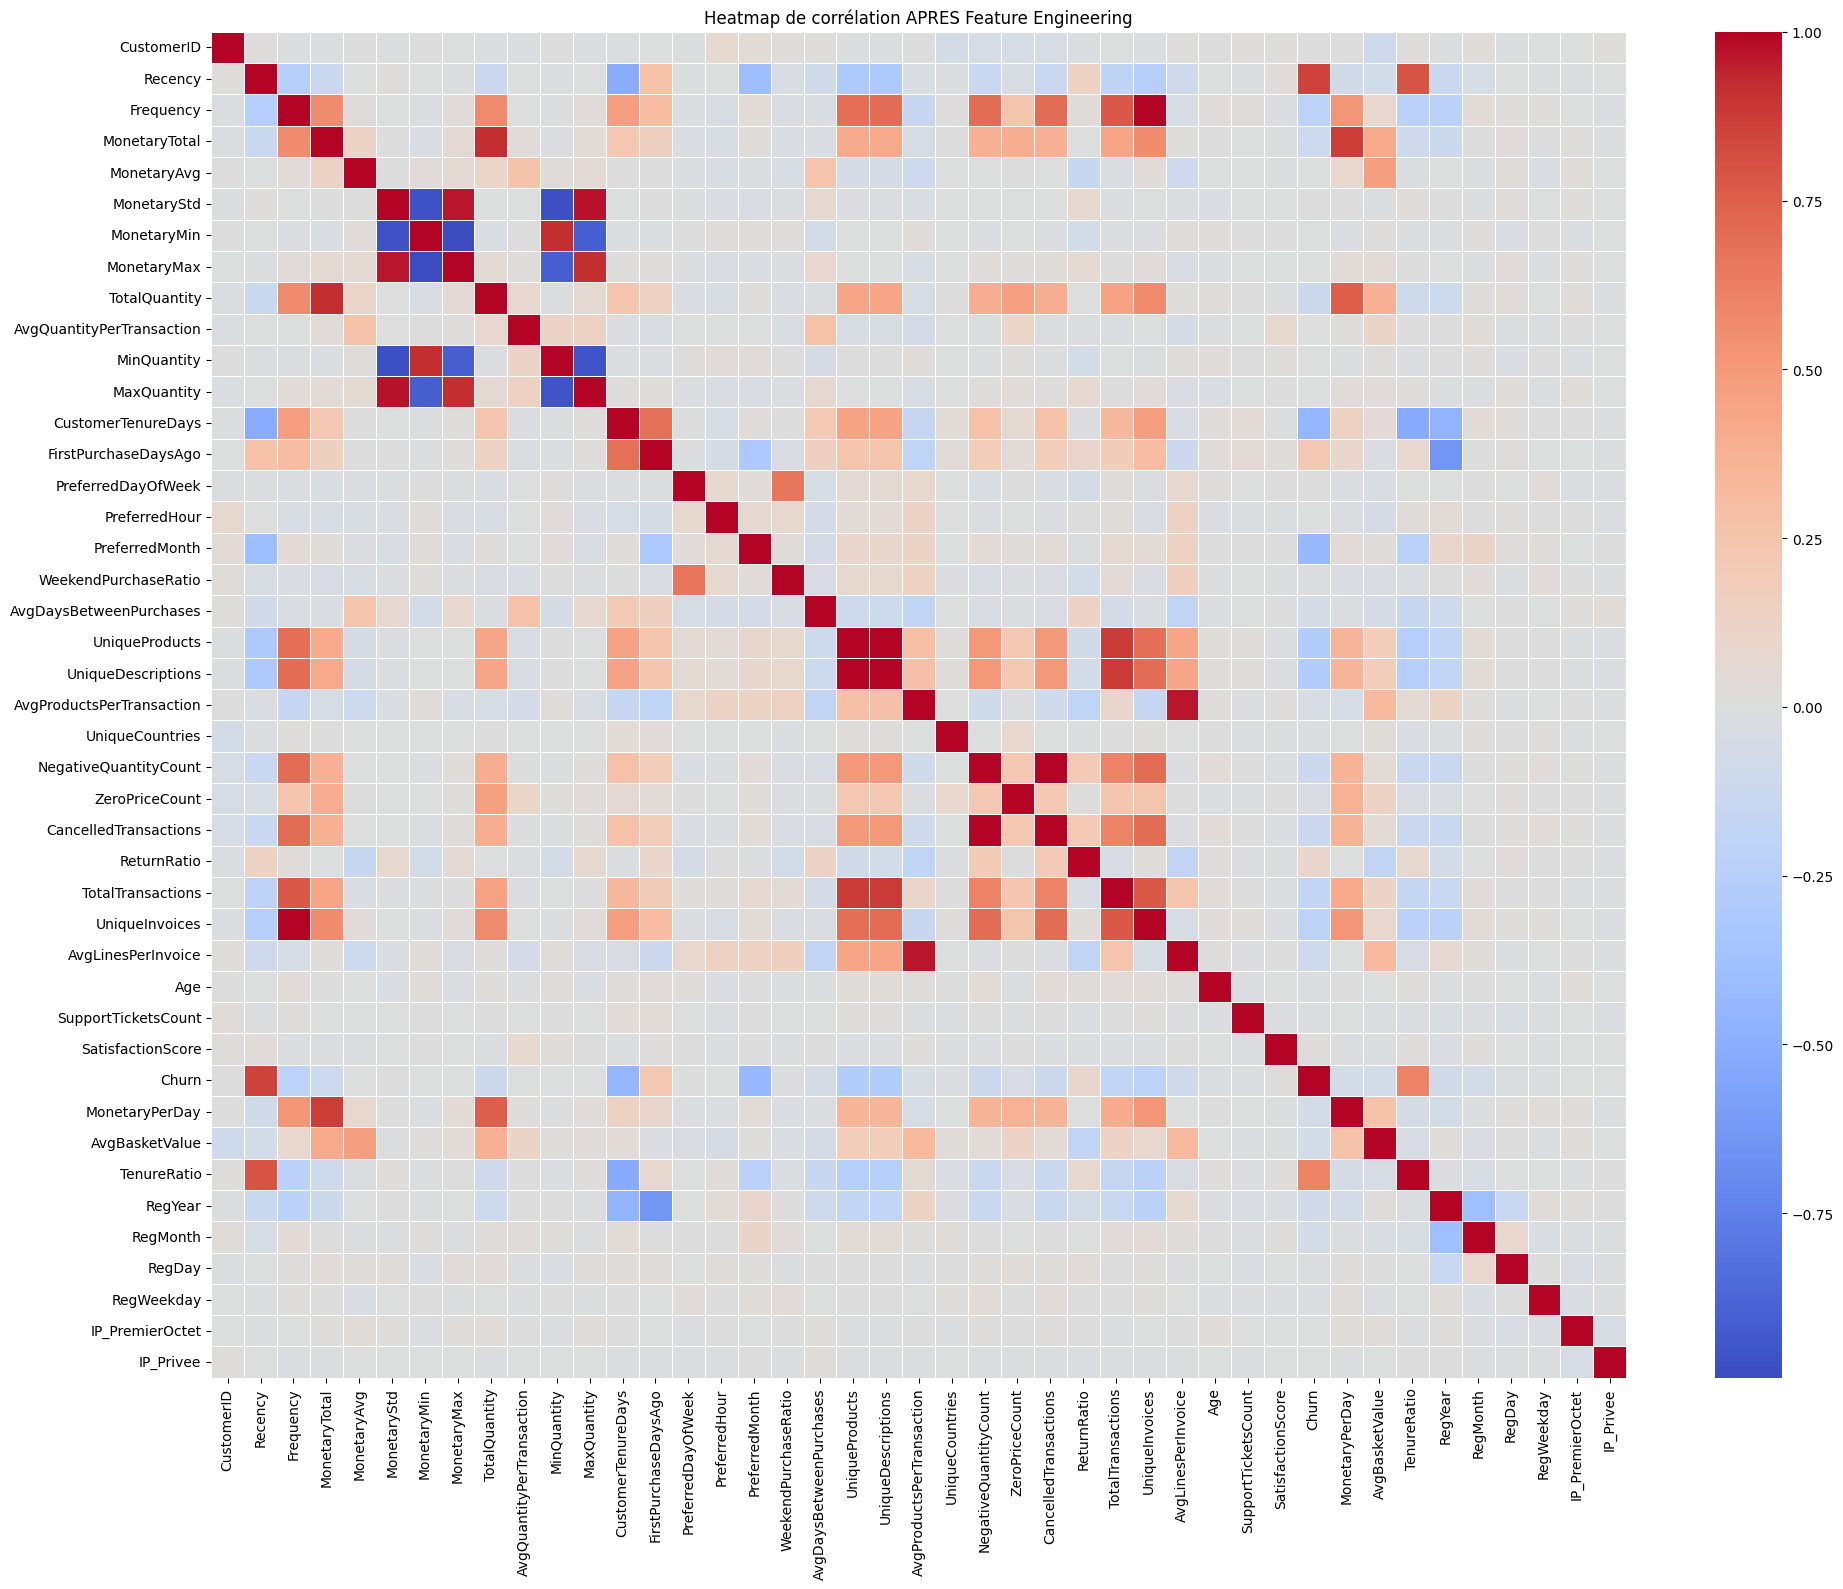

🔍 Features très corrélées (|corrélation| > 0.8) à examiner :
- Recency ↔ Churn : 0.86
- Frequency ↔ UniqueInvoices : 1.00
- MonetaryTotal ↔ TotalQuantity : 0.92
- MonetaryTotal ↔ MonetaryPerDay : 0.87
- MonetaryStd ↔ MonetaryMin : -0.97
- MonetaryStd ↔ MonetaryMax : 0.97
- MonetaryStd ↔ MinQuantity : -0.97
- MonetaryStd ↔ MaxQuantity : 0.97
- MonetaryMin ↔ MonetaryMax : -0.99
- MonetaryMin ↔ MinQuantity : 0.92
- MonetaryMin ↔ MaxQuantity : -0.92
- MonetaryMax ↔ MinQuantity : -0.92
- MonetaryMax ↔ MaxQuantity : 0.92
- MinQuantity ↔ MaxQuantity : -0.96
- UniqueProducts ↔ UniqueDescriptions : 1.00
- UniqueProducts ↔ TotalTransactions : 0.88
- UniqueDescriptions ↔ TotalTransactions : 0.88
- AvgProductsPerTransaction ↔ AvgLinesPerInvoice : 0.96
- NegativeQuantityCount ↔ CancelledTransactions : 1.00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ÉTAPE 1 : FEATURE ENGINEERING (Sur une copie de vos données brutes)

print("1. Lancement du Feature Engineering...")
df_test = df_raw.copy() # On travaille sur une copie pour ne pas casser df_raw

# Ratios financiers
if 'MonetaryTotal' in df_test.columns and 'Recency' in df_test.columns:
    df_test['MonetaryPerDay'] = df_test['MonetaryTotal'] / (df_test['Recency'] + 1)

if 'MonetaryTotal' in df_test.columns and 'Frequency' in df_test.columns:
    df_test['AvgBasketValue'] = df_test['MonetaryTotal'] / df_test['Frequency']

# Ratio d'engagement
if 'Recency' in df_test.columns and 'CustomerTenureDays' in df_test.columns:
    df_test['TenureRatio'] = df_test['Recency'] / (df_test['CustomerTenureDays'] + 1)

# Dates
if 'RegistrationDate' in df_test.columns:
    df_test['RegistrationDate'] = pd.to_datetime(df_test['RegistrationDate'], dayfirst=True, errors='coerce')
    df_test['RegYear']    = df_test['RegistrationDate'].dt.year
    df_test['RegMonth']   = df_test['RegistrationDate'].dt.month
    df_test['RegDay']     = df_test['RegistrationDate'].dt.day
    df_test['RegWeekday'] = df_test['RegistrationDate'].dt.weekday
    # On peut supprimer la date brute qui n'est plus utile
    df_test = df_test.drop(columns=['RegistrationDate'])

# Adresses IP
if 'LastLoginIP' in df_test.columns:
    df_test['IP_PremierOctet'] = df_test['LastLoginIP'].apply(
        lambda x: int(str(x).split('.')[0]) if pd.notna(x) else 0
    )
    df_test['IP_Privee'] = df_test['LastLoginIP'].apply(
        lambda x: 1 if str(x).startswith(('10.', '192.168.', '172.')) else 0 if pd.notna(x) else 0
    )
    df_test = df_test.drop(columns=['LastLoginIP'])

print(f"-> Shape après Feature Engineering : {df_test.shape}")

# ÉTAPE 2 : MATRICE DE CORRÉLATION ET HEATMAP

print("\n2. Affichage de la matrice de corrélation...")
plt.figure(figsize=(20, 16))

# Calcul (uniquement sur les colonnes numériques)
correlation_matrix = df_test.corr(numeric_only=True)

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=False,        
    cmap='coolwarm',    
    center=0,
    linewidths=0.5
)

plt.title('Heatmap de corrélation APRES Feature Engineering')
plt.tight_layout()
plt.show()

# ÉTAPE 3 : LISTER LES VARIABLES REDONDANTES (> 0.8)

print(" Features très corrélées (|corrélation| > 0.8) à examiner :")

paires_vues = set()

for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if col != row:
            valeur_corr = correlation_matrix[col][row]
            if abs(valeur_corr) > 0.8:
                paire = frozenset([col, row])
                
                if paire not in paires_vues:
                    print(f"- {col} ↔ {row} : {valeur_corr:.2f}")
                    paires_vues.add(paire)

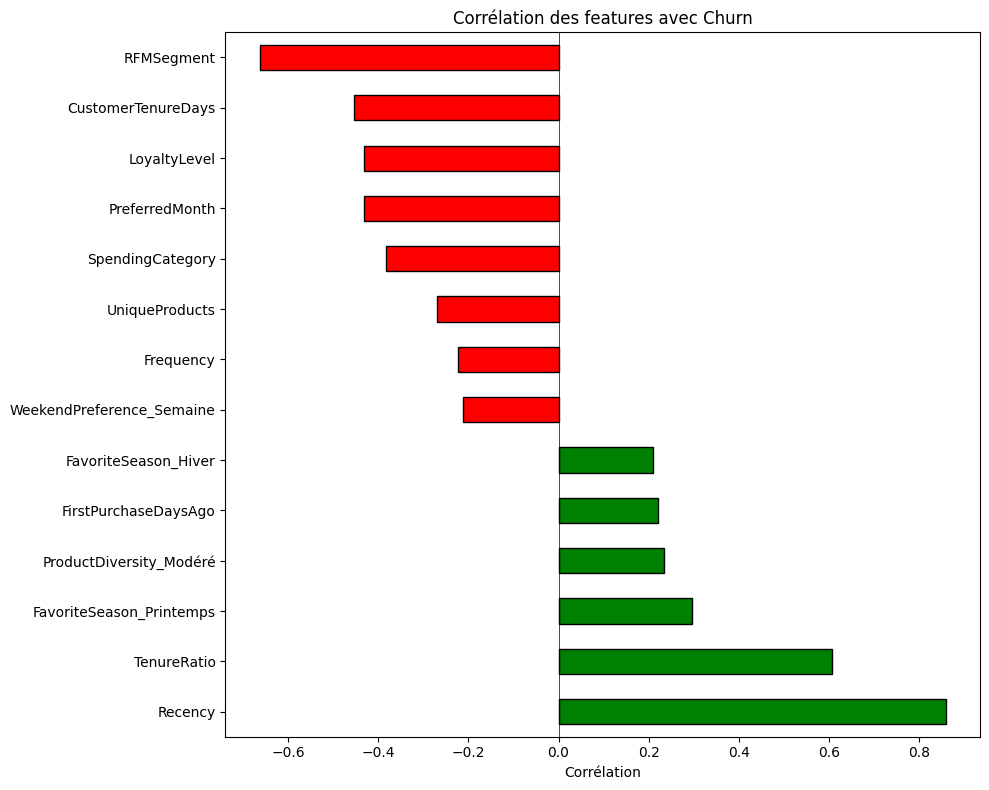

 Top 5 features qui AUGMENTENT le Churn :
Gender_M                      0.003848
MonetaryAvg                   0.004281
PreferredTimeOfDay            0.004776
RegDay                        0.009690
AgeCategory                   0.014665
SupportTicketsCount           0.018608
RegWeekday                    0.019849
WeekendPurchaseRatio          0.019857
Age                           0.020150
Region_Europe continentale    0.024525
Region_Europe du Nord         0.030826
ZeroPriceCount                0.031940
AvgProductsPerTransaction     0.037352
BasketSizeCategory            0.041354
AvgDaysBetweenPurchases       0.053000
AvgBasketValue                0.059724
RegMonth                      0.067209
MonetaryPerDay                0.071397
RegYear                       0.084044
MonetaryTotal                 0.111698
NegativeQuantityCount         0.128954
TotalTransactions             0.181653
WeekendPreference_Semaine     0.211657
Frequency                     0.222616
UniqueProducts        

: 

In [ ]:
plt.figure(figsize=(10, 8))

# Corrélation de toutes les features numériques avec Churn
correlation = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Supprimer Churn lui même
correlation = correlation.drop('Churn')
correlation_filtered = correlation[(correlation > 0.2) | (correlation < -0.2)]
# Graphique
correlation_filtered.plot(
    kind='barh',
    color=['red' if x < 0.2 else 'green' if x > -0.2 else 'gray' for x in correlation],
    edgecolor='black',
    figsize=(10, 8)
)

plt.title('Corrélation des features avec Churn')
plt.xlabel('Corrélation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
corr = abs(correlation)
# Top 5 features les plus corrélées
print(" Top 5 features qui AUGMENTENT le Churn :")
print(corr.tail(30))
print("\n Top 5 features qui DIMINUENT le Churn :")
print(correlation.tail(20))
# Pour trouver  quelles features sont vraiment liées au Churn — sans regarder chaque feature une par une.


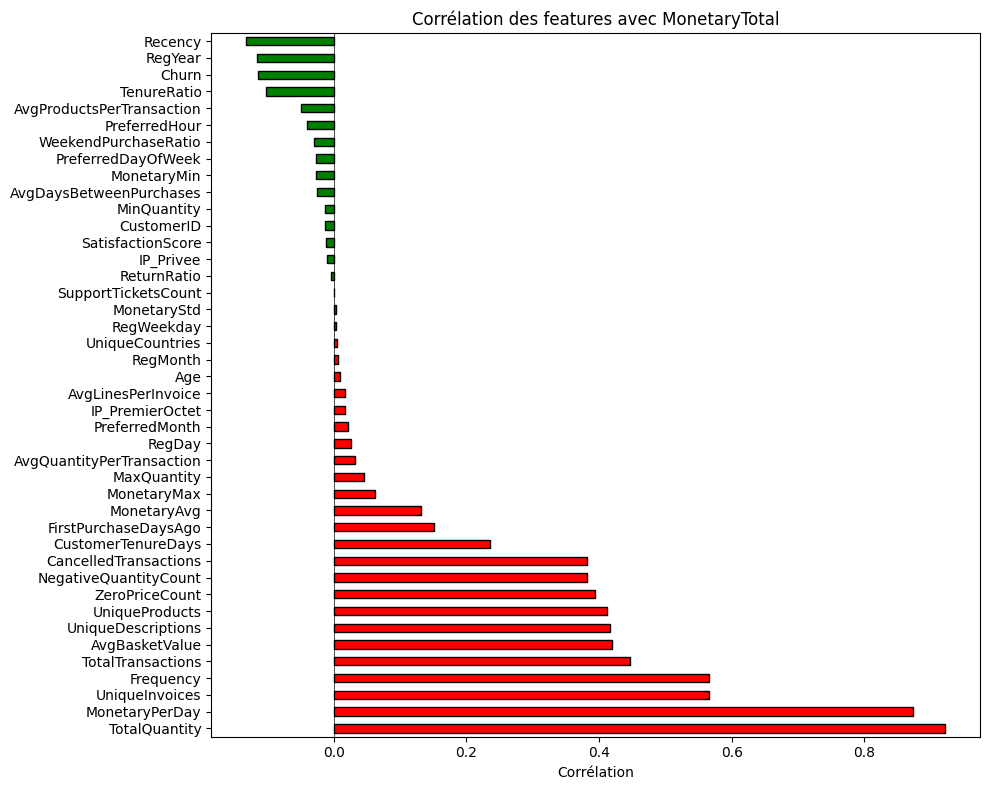

 Top  features qui AUGMENTENT le MonetaryTotal :
TotalQuantity        0.921649
MonetaryPerDay       0.873777
UniqueInvoices       0.566122
Frequency            0.566122
TotalTransactions    0.446622
Name: MonetaryTotal, dtype: float64

 Top  features qui DIMINUENT le MonetaryTotal :
AvgProductsPerTransaction   -0.048831
TenureRatio                 -0.101657
Churn                       -0.113630
RegYear                     -0.115907
Recency                     -0.132001
Name: MonetaryTotal, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))

# Corrélation de toutes les features numériques avec Churn
correlation = df_test.corr(numeric_only=True)['MonetaryTotal'].sort_values(ascending=False)

# Supprimer Churn lui même
correlation = correlation.drop('MonetaryTotal')

# Graphique
correlation.plot(kind='barh', 
                color=['red' if x > 0 else 'green' for x in correlation],
                edgecolor='black',
                figsize=(10, 8))

plt.title('Corrélation des features avec MonetaryTotal')
plt.xlabel('Corrélation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Top 5 features les plus corrélées
print(" Top  features qui AUGMENTENT le MonetaryTotal :")
print(correlation.head())
print("\n Top  features qui DIMINUENT le MonetaryTotal :")
print(correlation.tail())
# Pour trouver  quelles features sont vraiment liées au MonetaryTotal — sans regarder chaque feature une par une.


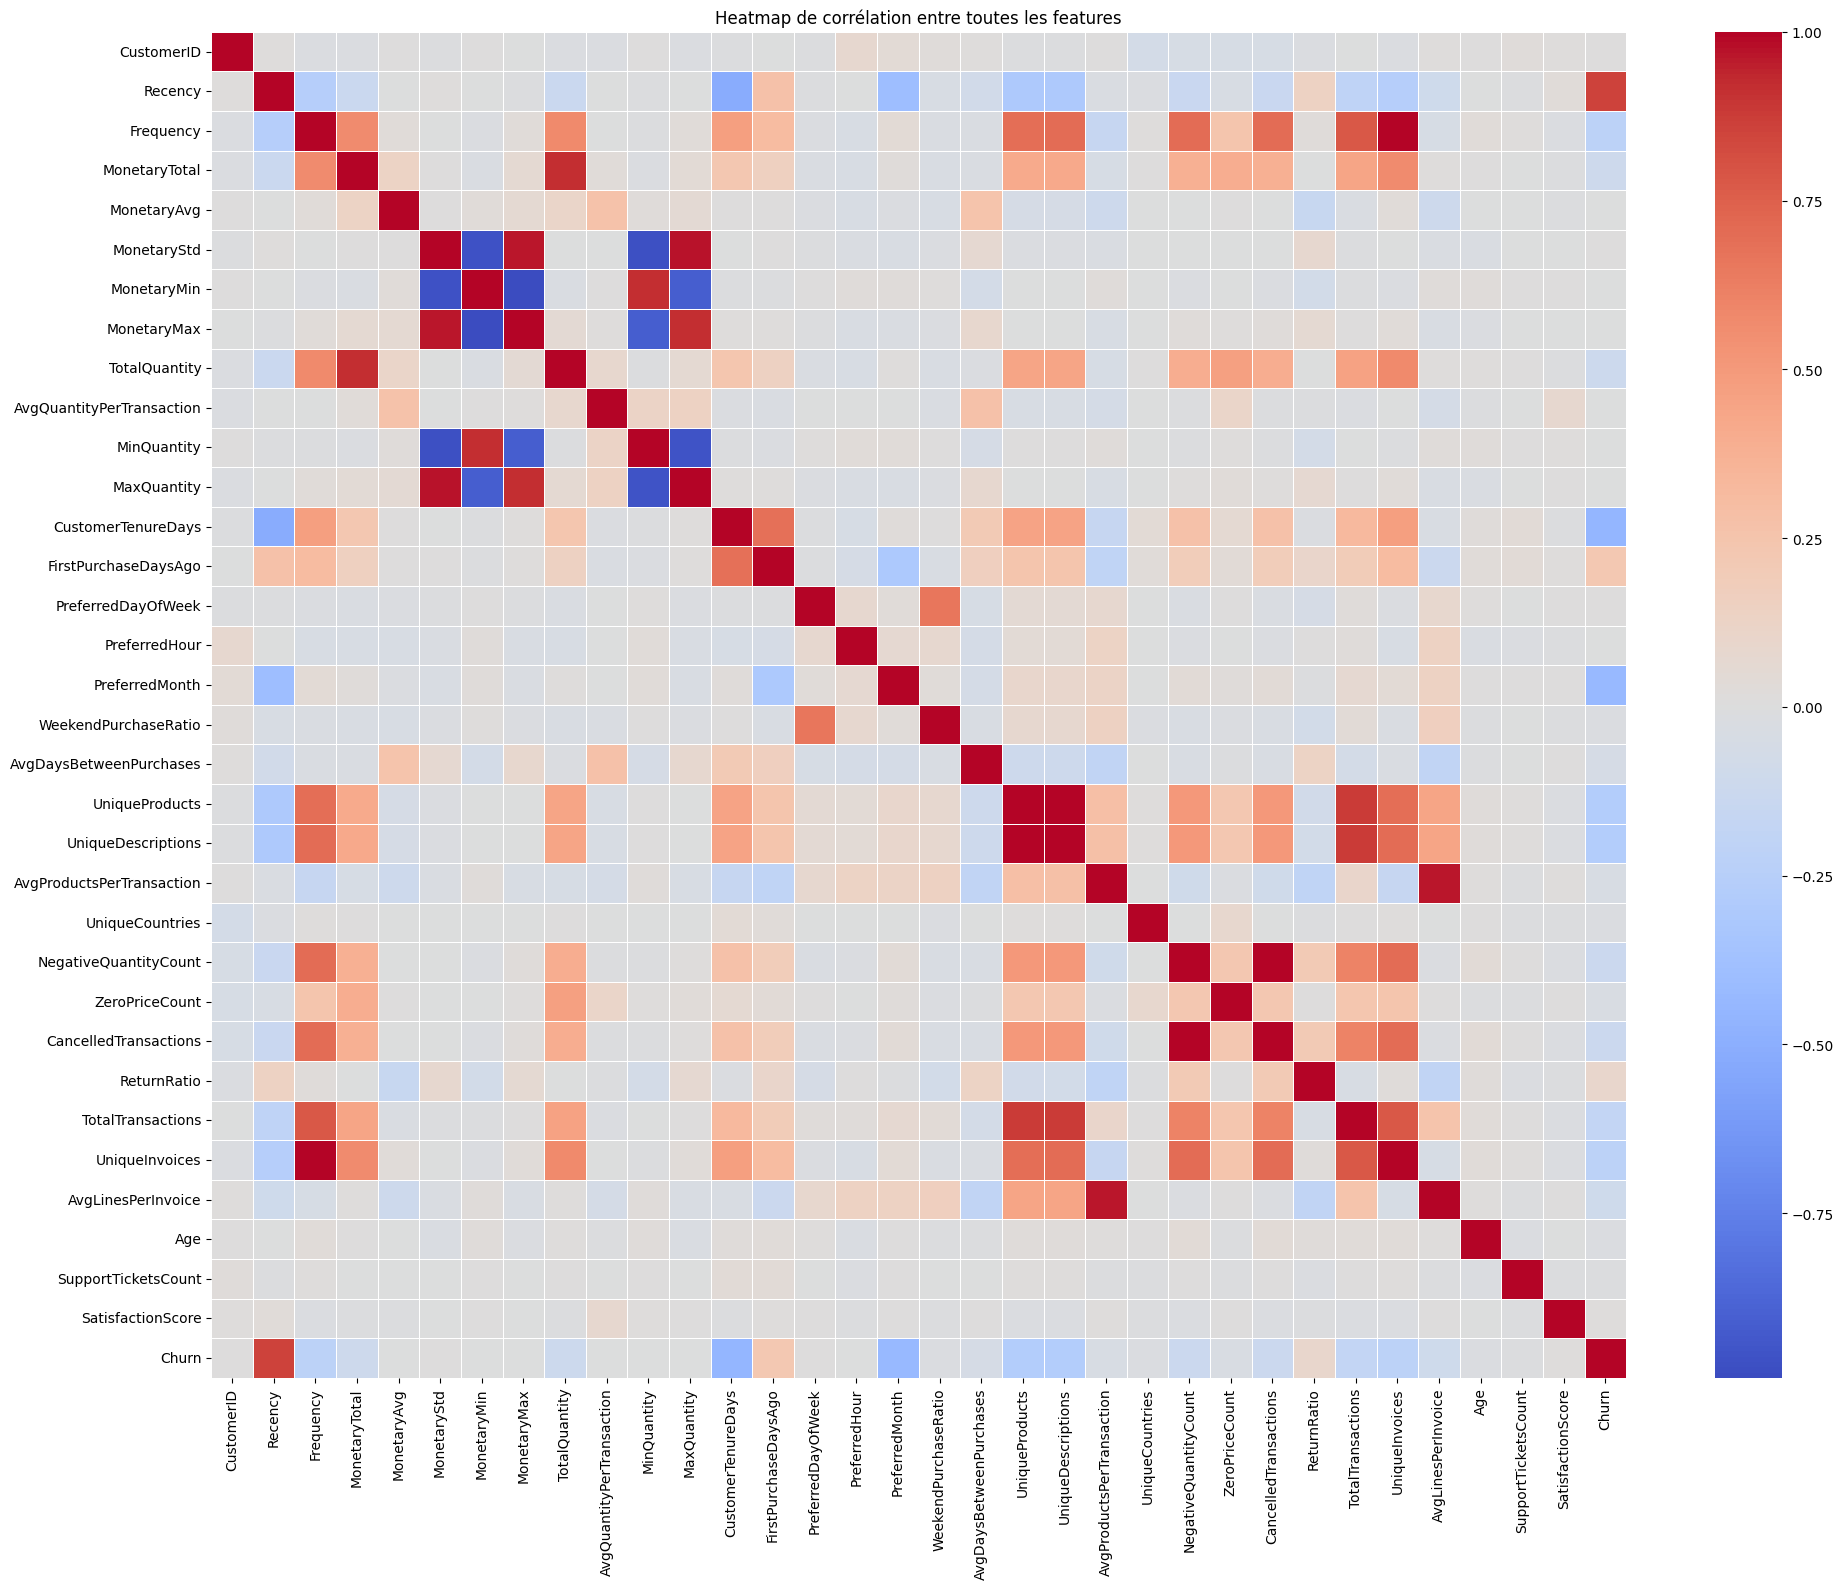

  Features très corrélées (|corrélation| > 0.8) :
Recency ↔ Churn : 0.86
Frequency ↔ UniqueInvoices : 1.00
MonetaryTotal ↔ TotalQuantity : 0.92
MonetaryStd ↔ MonetaryMin : -0.97
MonetaryStd ↔ MonetaryMax : 0.97
MonetaryStd ↔ MinQuantity : -0.97
MonetaryStd ↔ MaxQuantity : 0.97
MonetaryMin ↔ MonetaryStd : -0.97
MonetaryMin ↔ MonetaryMax : -0.99
MonetaryMin ↔ MinQuantity : 0.92
MonetaryMin ↔ MaxQuantity : -0.92
MonetaryMax ↔ MonetaryStd : 0.97
MonetaryMax ↔ MonetaryMin : -0.99
MonetaryMax ↔ MinQuantity : -0.92
MonetaryMax ↔ MaxQuantity : 0.92
TotalQuantity ↔ MonetaryTotal : 0.92
MinQuantity ↔ MonetaryStd : -0.97
MinQuantity ↔ MonetaryMin : 0.92
MinQuantity ↔ MonetaryMax : -0.92
MinQuantity ↔ MaxQuantity : -0.96
MaxQuantity ↔ MonetaryStd : 0.97
MaxQuantity ↔ MonetaryMin : -0.92
MaxQuantity ↔ MonetaryMax : 0.92
MaxQuantity ↔ MinQuantity : -0.96
UniqueProducts ↔ UniqueDescriptions : 1.00
UniqueProducts ↔ TotalTransactions : 0.88
UniqueDescriptions ↔ UniqueProducts : 1.00
UniqueDescriptions 

In [8]:
plt.figure(figsize=(20, 16))

# Calculer la matrice de corrélation
correlation_matrix = df_raw.corr(numeric_only=True)

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=False,        # pas de chiffres (trop de colonnes)
    cmap='coolwarm',    # rouge=corrélation positive, bleu=négative
    center=0,
    linewidths=0.5
)

plt.title('Heatmap de corrélation entre toutes les features')
plt.tight_layout()
plt.show()

# Features très corrélées entre elles (redondantes)
print("  Features très corrélées (|corrélation| > 0.8) :")
for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if col != row:
            if abs(correlation_matrix[col][row]) > 0.8:
                print(f"{col} ↔ {row} : {correlation_matrix[col][row]:.2f}")
# Pour détecter les features redondantes — deux features qui donnent la même information sont inutiles ensemble.


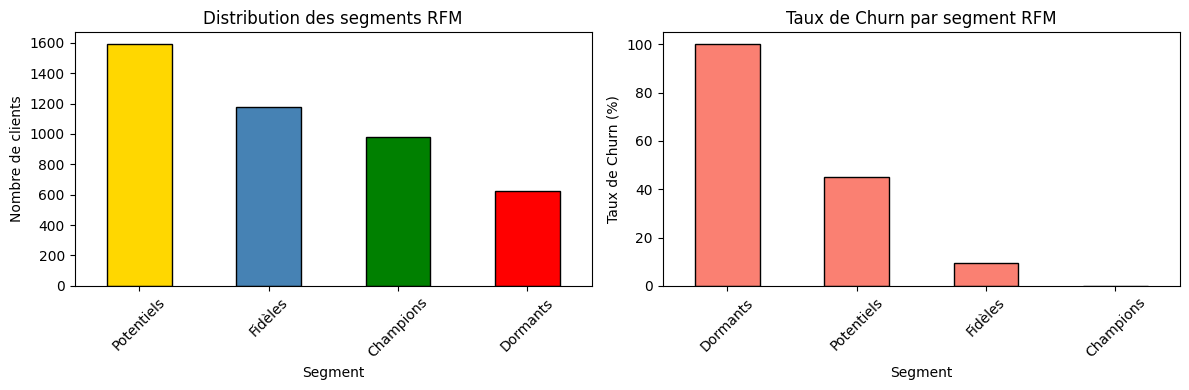

Taux de Churn par segment RFM :
RFMSegment
Champions       0.00
Dormants      100.00
Fidèles         9.35
Potentiels     45.12
Name: Churn, dtype: float64


In [21]:
plt.figure(figsize=(12, 4))

# Distribution des segments
plt.subplot(1, 2, 1)
df_raw['RFMSegment'].value_counts().plot(
    kind='bar',
    color=['gold', 'steelblue', 'green', 'red'],
    edgecolor='black'
)
plt.title('Distribution des segments RFM')
plt.xlabel('Segment')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=45)

# Churn par segment RFM
plt.subplot(1, 2, 2)
churn_par_segment = df_raw.groupby('RFMSegment')['Churn'].mean() * 100
churn_par_segment.sort_values(ascending=False).plot(
    kind='bar',
    color='salmon',
    edgecolor='black'
)
plt.title('Taux de Churn par segment RFM')
plt.xlabel('Segment')
plt.ylabel('Taux de Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Chiffres
print("Taux de Churn par segment RFM :")
print((df_raw.groupby('RFMSegment')['Churn'].mean() * 100).round(2))

In [15]:
import pandas as pd
import sys
sys.path.append(r'C:\Users\abdal\Desktop\projects\ML\ML_project\src')
from utils import analyser_redondantes

df = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\raw\retail_customers_COMPLETE CATEGORICAL.csv')

# Vérification faille 1
colonnes = analyser_redondantes(df, seuil=0.85)
print('Recency supprimée ?', 'Recency' in colonnes)
print('Churn supprimé ?', 'Churn' in colonnes)

# Vérification faille 2
print('\nCorrélation TotalQuantity vs MonetaryTotal vs Churn:')
print(df[['TotalQuantity', 'MonetaryTotal', 'Churn']].corr())


 COLONNES REDONDANTES (corrélation > 0.85)
 UniqueInvoices redondante avec Frequency (corrélation = 1.00)
 TotalQuantity redondante avec MonetaryTotal (corrélation = 0.92)
 MonetaryMin redondante avec MonetaryStd (corrélation = -0.97)
 MonetaryMax redondante avec MonetaryStd (corrélation = 0.97)
 MinQuantity redondante avec MonetaryStd (corrélation = -0.97)
 MaxQuantity redondante avec MonetaryStd (corrélation = 0.97)
 UniqueDescriptions redondante avec UniqueProducts (corrélation = 1.00)
 TotalTransactions redondante avec UniqueProducts (corrélation = 0.88)
 AvgLinesPerInvoice redondante avec AvgProductsPerTransaction (corrélation = 0.96)
 CancelledTransactions redondante avec NegativeQuantityCount (corrélation = 1.00)

→ 10 colonnes redondantes détectées
Recency supprimée ? False
Churn supprimé ? False

Corrélation TotalQuantity vs MonetaryTotal vs Churn:
               TotalQuantity  MonetaryTotal     Churn
TotalQuantity       1.000000       0.921649 -0.116986
MonetaryTotal       0